# Advanced Analytics & Risk Metrics

## Objective

This notebook extends the Mutual Fund Analytics project with advanced risk, investor behavior and portfolio concentration analysis.

The analysis covers:

1. Historical Value at Risk (VaR)
2. Conditional Value at Risk (CVaR)
3. Rolling 90-Day Sharpe Ratio
4. Investor Cohort Analysis
5. SIP Continuity Analysis
6. Risk-Based Fund Recommendation
7. Sector Concentration using HHI
8. Advanced Investment Insights

The objective is to identify downside risk, risk-adjusted performance, investor behavior patterns and portfolio concentration across the mutual fund universe.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from IPython.display import display

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nProject files:")
for item in os.listdir():
    print(item)

Current working directory:
d:\mutual-fund-analysis\notebooks

Project files:
Advanced_Analytics.ipynb
benchmark_summary.csv
EDA_Analysis.ipynb
final_project_qa.ipynb
fund_scorecard.csv
neda_analysis.ipynb
normalized_benchmark_performance.csv
normalized_benchmark_performance.png
Performance_Analytics.ipynb
python_data_analysis.ipynb
rolling_30d_tracking_difference.csv
rolling_30d_tracking_difference_nifty100.png
rolling_30d_tracking_difference_nifty50.png
tracking_error_comparison.csv


In [4]:
print("\nProcessed data files:")

if os.path.exists("data/processed"):
    for file in os.listdir("data/processed"):
        print(file)
else:
    print("❌ data/processed folder not found")


Processed data files:
❌ data/processed folder not found


In [5]:
import os

project_path = ".."

print("Project folder:")
print(os.path.abspath(project_path))

print("\nProject contents:")

for item in os.listdir(project_path):
    print(item)

Project folder:
d:\mutual-fund-analysis

Project contents:
.gitignore
bluestock_mf.db
dashboard
data
data_dictionary.md
notebooks
README.md
reports
requirements.txt
scripts
sql
sql analysis.sql
var_cvar_report.csv


In [6]:
processed_path = "../data/processed"

print(
    "Processed folder:",
    os.path.abspath(processed_path)
)

if os.path.exists(processed_path):

    print("\n✅ data/processed exists")

    print("\nFiles:")

    for file in os.listdir(processed_path):
        print(file)

else:

    print("\n❌ data/processed still not found")

Processed folder: d:\mutual-fund-analysis\data\processed

✅ data/processed exists

Files:
alpha_beta.csv
cagr_comparison.csv
cagr_metrics.csv
cleaned_scheme_performance.csv
investor_transactions_cleaned.csv
maximum_drawdown.csv
max_drawdown.csv
nav_history_cleaned.csv
sharpe_ratio.csv
sortino_ratio.csv
tracking_error.csv


In [7]:
import pandas as pd
import numpy as np
import os

# Load cleaned NAV data
nav = pd.read_csv(
    "../data/processed/nav_history_cleaned.csv"
)

print("NAV shape:", nav.shape)

print("\nNAV columns:")
print(nav.columns.tolist())

print("\nFirst 5 rows:")
display(nav.head())

NAV shape: (46000, 3)

NAV columns:
['amfi_code', 'date', 'nav']

First 5 rows:


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
investor_transactions = pd.read_csv(
    "../data/processed/investor_transactions_cleaned.csv"
)

print("Investor transaction shape:")
print(investor_transactions.shape)

print("\nColumns:")
print(investor_transactions.columns.tolist())

print("\nFirst 5 rows:")
display(investor_transactions.head())

Investor transaction shape:
(32778, 13)

Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

First 5 rows:


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [9]:
scheme_performance = pd.read_csv(
    "../data/processed/cleaned_scheme_performance.csv"
)

print("Scheme performance shape:")
print(scheme_performance.shape)

print("\nColumns:")
print(scheme_performance.columns.tolist())

print("\nFirst 5 rows:")
display(scheme_performance.head())

Scheme performance shape:
(42, 19)

Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

First 5 rows:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288.0,1.54,4.0,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231.0,0.66,3.0,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259.0,1.43,5.0,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061.0,0.72,4.0,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101.0,0.77,5.0,Low


In [9]:
# ============================================================
# ADVANCED ANALYTICS — STEP 1
# Load and prepare NAV data
# ============================================================

import pandas as pd
import numpy as np
import os

nav = pd.read_csv(
    "../data/processed/nav_history_cleaned.csv"
)

print("NAV Shape:", nav.shape)

print("\nColumns:")
print(nav.columns.tolist())

print("\nFirst 5 rows:")
display(nav.head())

NAV Shape: (46000, 3)

Columns:
['amfi_code', 'date', 'nav']

First 5 rows:


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [10]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [11]:
display(nav.head())

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [15]:
# ============================================================
# STEP 2 — HISTORICAL VaR & CVaR (95%)
# ============================================================

import pandas as pd
import numpy as np

# Load NAV data
nav = pd.read_csv(
    "../data/processed/nav_history_cleaned.csv"
)

# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Sort properly
nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

# Calculate daily returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print("Daily return calculation completed.")

# Display only columns that actually exist
display(
    nav[
        [
            "amfi_code",
            "date",
            "nav",
            "daily_return"
        ]
    ].head(10)
)

print("\nNAV shape:", nav.shape)
print(
    "Number of schemes:",
    nav["amfi_code"].nunique()
)

Daily return calculation completed.


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073



NAV shape: (46000, 4)
Number of schemes: 40


In [16]:
# ============================================================
# STEP 3 — CALCULATE VaR & CVaR FOR ALL SCHEMES
# ============================================================

var_cvar_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    # 95% Historical VaR
    var_95 = returns.quantile(0.05)

    # 95% Historical CVaR
    tail_returns = returns[
        returns <= var_95
    ]

    cvar_95 = tail_returns.mean()

    var_cvar_results.append({
        "amfi_code": amfi_code,
        "observations": len(returns),
        "VaR_95_pct": var_95 * 100,
        "CVaR_95_pct": cvar_95 * 100
    })

var_cvar_report = pd.DataFrame(
    var_cvar_results
)

var_cvar_report = (
    var_cvar_report
    .sort_values("VaR_95_pct")
    .reset_index(drop=True)
)

print("VaR/CVaR calculation completed.")
print("Number of schemes:", len(var_cvar_report))

display(var_cvar_report.head(10))

VaR/CVaR calculation completed.
Number of schemes: 40


,amfi_code,observations,VaR_95_pct,CVaR_95_pct
0,119599,1149,-2.685944,-3.238412
1,119095,1149,-2.618842,-3.166729
2,101207,1149,-2.602125,-3.245906
3,118634,1149,-2.543811,-3.230407
4,119598,1149,-2.450705,-3.059526
5,149324,1149,-2.348307,-3.103625
6,102886,1149,-1.922028,-2.325086
7,100033,1149,-1.903354,-2.345576
8,120505,1149,-1.889179,-2.434207
9,119094,1149,-1.848028,-2.426006


In [17]:
# ============================================================
# STEP 4 — VaR / CVaR VALIDATION
# ============================================================

print("=" * 60)
print("VaR / CVaR VALIDATION")
print("=" * 60)

print("\nShape:")
print(var_cvar_report.shape)

print("\nMissing values:")
display(var_cvar_report.isna().sum())

print("\nVaR statistics:")
display(
    var_cvar_report["VaR_95_pct"].describe()
)

print("\nCVaR statistics:")
display(
    var_cvar_report["CVaR_95_pct"].describe()
)

# Check whether CVaR is more negative than or equal to VaR
violations = (
    var_cvar_report["CVaR_95_pct"]
    >
    var_cvar_report["VaR_95_pct"]
).sum()

print(
    "\nCVaR > VaR violations:",
    violations
)

# Number of schemes
if len(var_cvar_report) == 40:
    print("✅ Exactly 40 schemes found.")
else:
    print(
        f"⚠️ Expected 40 schemes, "
        f"but found {len(var_cvar_report)}."
    )

# CVaR relationship
if violations == 0:
    print("✅ CVaR/VaR relationship passed.")
else:
    print("⚠️ CVaR/VaR relationship needs review.")

VaR / CVaR VALIDATION

Shape:
(40, 4)

Missing values:


amfi_code       0
observations    0
VaR_95_pct      0
CVaR_95_pct     0
dtype: int64


VaR statistics:


count    40.000000
mean     -1.471084
std       0.682073
min      -2.685944
25%      -1.839406
50%      -1.437605
75%      -1.324669
max      -0.022157
Name: VaR_95_pct, dtype: float64


CVaR statistics:


count    40.000000
mean     -1.858018
std       0.847596
min      -3.245906
25%      -2.313306
50%      -1.818505
75%      -1.657184
max      -0.037258
Name: CVaR_95_pct, dtype: float64


CVaR > VaR violations: 0
✅ Exactly 40 schemes found.
✅ CVaR/VaR relationship passed.


In [19]:
# ============================================================
# STEP 5 — ADD SCHEME NAMES
# ============================================================

scorecard = pd.read_csv(
    r"D:\mutual-fund-analysis\notebooks\fund_scorecard.csv"
)

# Make AMFI codes consistent
var_cvar_report["amfi_code"] = (
    var_cvar_report["amfi_code"]
    .astype(str)
    .str.strip()
)

scorecard["amfi_code"] = (
    scorecard["amfi_code"]
    .astype(str)
    .str.strip()
)

# Merge fund names
var_cvar_report = var_cvar_report.merge(
    scorecard[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

# Arrange columns
var_cvar_report = var_cvar_report[
    [
        "amfi_code",
        "scheme_name",
        "observations",
        "VaR_95_pct",
        "CVaR_95_pct"
    ]
]

print("Scheme names added successfully.")

display(var_cvar_report.head(10))

Scheme names added successfully.


,amfi_code,scheme_name,observations,VaR_95_pct,CVaR_95_pct
0,119599,SBI Small Cap Fund - Direct Plan - Growth,1149,-2.685944,-3.238412
1,119095,Axis Small Cap Fund - Regular - Growth,1149,-2.618842,-3.166729
2,101207,ABSL Small Cap Fund - Regular - Growth,1149,-2.602125,-3.245906
3,118634,Nippon India Small Cap Fund - Regular - Growth,1149,-2.543811,-3.230407
4,119598,SBI Small Cap Fund - Regular Plan - Growth,1149,-2.450705,-3.059526
5,149324,DSP Small Cap Fund - Regular - Growth,1149,-2.348307,-3.103625
6,102886,UTI Mid Cap Fund - Regular - Growth,1149,-1.922028,-2.325086
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1149,-1.903354,-2.345576
8,120505,ICICI Pru Midcap Fund - Regular - Growth,1149,-1.889179,-2.434207
9,119094,Axis Midcap Fund - Regular - Growth,1149,-1.848028,-2.426006


In [20]:
# ============================================================
# STEP 6 — SAVE VaR/CVaR REPORT
# ============================================================

output_path = "../var_cvar_report.csv"

var_cvar_report.to_csv(
    output_path,
    index=False
)

print(
    "✅ var_cvar_report.csv created successfully."
)
print(
    "Location:",
    os.path.abspath(output_path)
)

✅ var_cvar_report.csv created successfully.
Location: d:\mutual-fund-analysis\var_cvar_report.csv


In [21]:
print(
    "Final shape:",
    var_cvar_report.shape
)

print(
    "Missing scheme names:",
    var_cvar_report["scheme_name"].isna().sum()
)

display(
    var_cvar_report[
        [
            "scheme_name",
            "VaR_95_pct",
            "CVaR_95_pct"
        ]
    ].head(5)
)

Final shape: (40, 5)
Missing scheme names: 0


,scheme_name,VaR_95_pct,CVaR_95_pct
0,SBI Small Cap Fund - Direct Plan - Growth,-2.685944,-3.238412
1,Axis Small Cap Fund - Regular - Growth,-2.618842,-3.166729
2,ABSL Small Cap Fund - Regular - Growth,-2.602125,-3.245906
3,Nippon India Small Cap Fund - Regular - Growth,-2.543811,-3.230407
4,SBI Small Cap Fund - Regular Plan - Growth,-2.450705,-3.059526


In [22]:
print("🔴 Highest downside-risk funds:")
display(
    var_cvar_report[
        [
            "scheme_name",
            "VaR_95_pct",
            "CVaR_95_pct"
        ]
    ].head(5)
)

🔴 Highest downside-risk funds:


,scheme_name,VaR_95_pct,CVaR_95_pct
0,SBI Small Cap Fund - Direct Plan - Growth,-2.685944,-3.238412
1,Axis Small Cap Fund - Regular - Growth,-2.618842,-3.166729
2,ABSL Small Cap Fund - Regular - Growth,-2.602125,-3.245906
3,Nippon India Small Cap Fund - Regular - Growth,-2.543811,-3.230407
4,SBI Small Cap Fund - Regular Plan - Growth,-2.450705,-3.059526


In [23]:
# ============================================================
# STEP 7 — SELECT TOP 5 FUNDS
# ============================================================

scorecard = pd.read_csv(
    r"D:\mutual-fund-analysis\notebooks\fund_scorecard.csv"
)

# Ensure AMFI codes have the same format
scorecard["amfi_code"] = (
    scorecard["amfi_code"]
    .astype(str)
    .str.strip()
)

top5_funds = (
    scorecard
    .sort_values("Overall_Rank")
    .head(5)
    [
        [
            "amfi_code",
            "scheme_name",
            "Overall_Rank"
        ]
    ]
    .copy()
)

print("TOP 5 FUNDS")
print("=" * 60)

display(top5_funds)

TOP 5 FUNDS


,amfi_code,scheme_name,Overall_Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1
1,120843,Kotak Flexicap Fund - Regular - Growth,2
2,120507,ICICI Pru Liquid Fund - Regular - Growth,3
3,120504,ICICI Pru Bluechip Fund - Direct - Growth,4
4,100025,HDFC Short Term Debt Fund - Regular - Growth,5


In [24]:
# ============================================================
# STEP 8 — FILTER NAV FOR TOP 5 FUNDS
# ============================================================

nav["amfi_code"] = (
    nav["amfi_code"]
    .astype(str)
    .str.strip()
)

top5_codes = set(
    top5_funds["amfi_code"]
)

top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

top5_nav = top5_nav.sort_values(
    ["amfi_code", "date"]
)

print("Top 5 NAV shape:", top5_nav.shape)

print(
    "Number of funds found:",
    top5_nav["amfi_code"].nunique()
)

print("\nFunds found:")
print(
    top5_nav["amfi_code"].unique()
)

Top 5 NAV shape: (5750, 4)
Number of funds found: 5

Funds found:
['100025' '120504' '120507' '120843' '148567']


In [25]:
# ============================================================
# STEP 9 — ROLLING 90-DAY SHARPE RATIO
# ============================================================

top5_nav["Rolling_90D_Sharpe"] = (
    top5_nav
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        (
            x.rolling(
                window=90,
                min_periods=90
            ).mean()
            /
            x.rolling(
                window=90,
                min_periods=90
            ).std()
        ) * np.sqrt(252)
    )
)

print("✅ Rolling 90-day Sharpe calculated.")

display(
    top5_nav[
        [
            "amfi_code",
            "date",
            "daily_return",
            "Rolling_90D_Sharpe"
        ]
    ].tail(10)
)

✅ Rolling 90-day Sharpe calculated.


,amfi_code,date,daily_return,Rolling_90D_Sharpe
40240,148567,2026-05-18,-0.011253,0.375292
40241,148567,2026-05-19,0.001771,0.234290
40242,148567,2026-05-20,-0.018615,0.023921
40243,148567,2026-05-21,0.005362,0.022737
40244,148567,2026-05-22,0.006322,0.610167
40245,148567,2026-05-25,-0.013787,0.305637
40246,148567,2026-05-26,0.002199,0.404207
40247,148567,2026-05-27,0.005080,0.143232
40248,148567,2026-05-28,0.008847,0.626656
40249,148567,2026-05-29,-0.012362,0.375893


In [26]:
# ============================================================
# STEP 10 — ADD FUND NAMES
# ============================================================

top5_nav = top5_nav.merge(
    top5_funds[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

print("✅ Fund names added.")

display(
    top5_nav[
        [
            "date",
            "amfi_code",
            "scheme_name",
            "Rolling_90D_Sharpe"
        ]
    ].tail(10)
)

✅ Fund names added.


,date,amfi_code,scheme_name,Rolling_90D_Sharpe
5740,2026-05-18,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.375292
5741,2026-05-19,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.234290
5742,2026-05-20,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.023921
5743,2026-05-21,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.022737
5744,2026-05-22,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.610167
5745,2026-05-25,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.305637
5746,2026-05-26,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.404207
5747,2026-05-27,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.143232
5748,2026-05-28,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.626656
5749,2026-05-29,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.375893


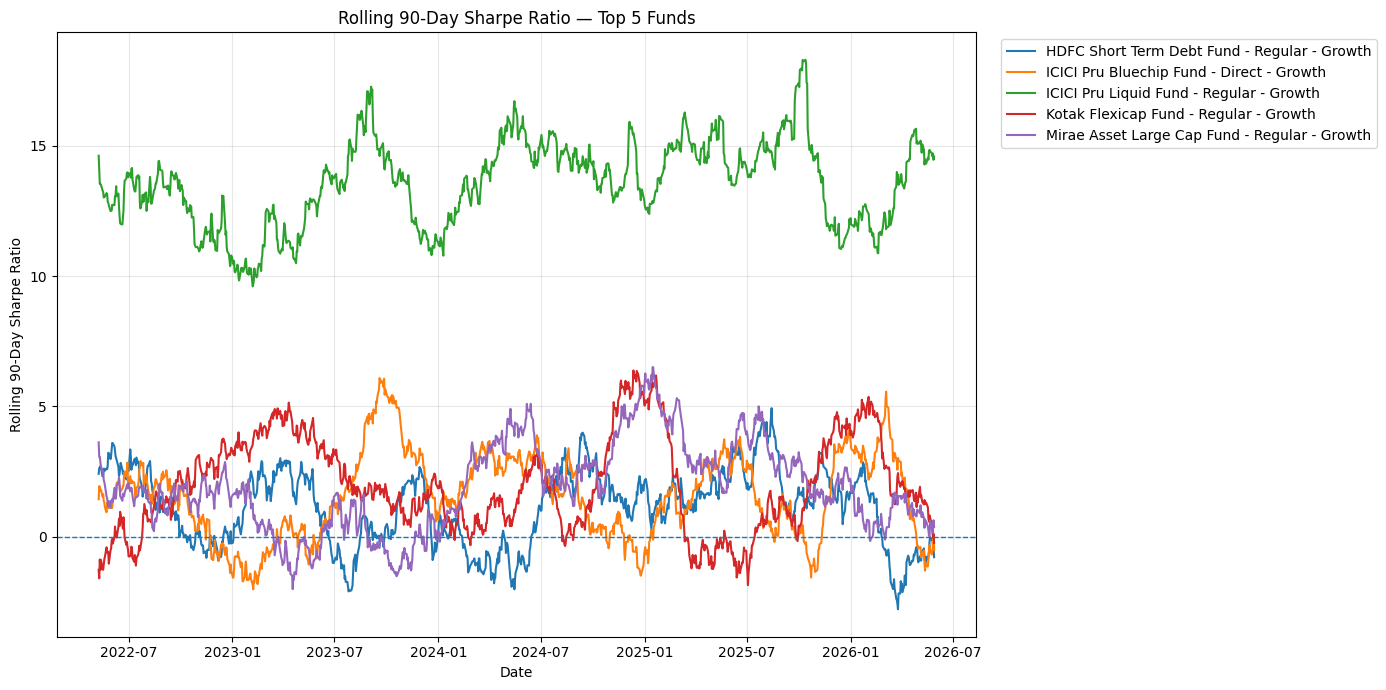

✅ rolling_sharpe_chart.png created successfully.


In [27]:
# ============================================================
# STEP 11 — ROLLING 90-DAY SHARPE CHART
# ============================================================

plt.figure(figsize=(14, 7))

for fund in top5_nav["scheme_name"].dropna().unique():

    temp = top5_nav[
        top5_nav["scheme_name"] == fund
    ].sort_values("date")

    plt.plot(
        temp["date"],
        temp["Rolling_90D_Sharpe"],
        label=fund,
        linewidth=1.5
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Rolling 90-Day Sharpe Ratio — Top 5 Funds"
)

plt.xlabel("Date")
plt.ylabel("Rolling 90-Day Sharpe Ratio")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ rolling_sharpe_chart.png created successfully.")

In [28]:
# ============================================================
# STEP 12 — ROLLING SHARPE VALIDATION
# ============================================================

print("=" * 60)
print("ROLLING 90-DAY SHARPE VALIDATION")
print("=" * 60)

print(
    "\nNumber of funds:",
    top5_nav["scheme_name"].nunique()
)

print(
    "Total observations:",
    len(top5_nav)
)

print(
    "Valid Rolling Sharpe observations:",
    top5_nav["Rolling_90D_Sharpe"].notna().sum()
)

print("\nSharpe statistics:")

display(
    top5_nav[
        "Rolling_90D_Sharpe"
    ].describe()
)

if top5_nav["scheme_name"].nunique() == 5:
    print("✅ Exactly 5 funds included.")
else:
    print("⚠️ Expected 5 funds.")

if top5_nav["Rolling_90D_Sharpe"].notna().sum() > 0:
    print("✅ Rolling 90-day Sharpe calculated.")
else:
    print("❌ No valid Rolling Sharpe values.")

ROLLING 90-DAY SHARPE VALIDATION

Number of funds: 5
Total observations: 5750
Valid Rolling Sharpe observations: 5300

Sharpe statistics:


count    5300.000000
mean        4.026718
std         5.047295
min        -2.789428
25%         0.788968
50%         2.090032
75%         4.493950
max        18.299609
Name: Rolling_90D_Sharpe, dtype: float64

✅ Exactly 5 funds included.
✅ Rolling 90-day Sharpe calculated.


In [29]:
# ============================================================
# STEP 13 — LOAD INVESTOR TRANSACTIONS
# ============================================================

investor_transactions = pd.read_csv(
    "../data/processed/investor_transactions_cleaned.csv"
)

print("Investor transaction shape:")
print(investor_transactions.shape)

print("\nColumns:")
print(investor_transactions.columns.tolist())

print("\nFirst 5 rows:")
display(investor_transactions.head())

Investor transaction shape:
(32778, 13)

Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

First 5 rows:


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [30]:
# ============================================================
# STEP 14 — INSPECT TRANSACTION DATA
# ============================================================

print(investor_transactions.dtypes)

print("\nMissing values:")
display(
    investor_transactions.isna().sum()
)

investor_id            object
transaction_date       object
amfi_code               int64
transaction_type       object
amount_inr              int64
state                  object
city                   object
city_tier              object
age_group              object
gender                 object
annual_income_lakh    float64
payment_mode           object
kyc_status             object
dtype: object

Missing values:


investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

In [31]:
print(investor_transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [32]:
# ============================================================
# STEP 15 — PREPARE INVESTOR TRANSACTIONS
# ============================================================

investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"]
)

investor_transactions["transaction_type"] = (
    investor_transactions["transaction_type"]
    .astype(str)
    .str.strip()
    .str.upper()
)

investor_transactions["amount_inr"] = pd.to_numeric(
    investor_transactions["amount_inr"],
    errors="coerce"
)

print("Transaction dates:")
print(
    investor_transactions["transaction_date"].min(),
    "to",
    investor_transactions["transaction_date"].max()
)

print("\nTransaction types:")
print(
    investor_transactions["transaction_type"].value_counts()
)

print("\nMissing values:")
display(
    investor_transactions[
        [
            "investor_id",
            "transaction_date",
            "amfi_code",
            "transaction_type",
            "amount_inr"
        ]
    ].isna().sum()
)

Transaction dates:
2024-01-01 00:00:00 to 2025-05-30 00:00:00

Transaction types:
transaction_type
SIP           19716
LUMPSUM        8095
REDEMPTION     4967
Name: count, dtype: int64

Missing values:


investor_id         0
transaction_date    0
amfi_code           0
transaction_type    0
amount_inr          0
dtype: int64

In [33]:
# ============================================================
# STEP 16 — INVESTOR COHORT YEAR
# ============================================================

first_transaction = (
    investor_transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
    .rename(
        columns={
            "transaction_date": "first_transaction_date"
        }
    )
)

first_transaction["cohort_year"] = (
    first_transaction["first_transaction_date"]
    .dt.year
)

print("Number of unique investors:")
print(first_transaction["investor_id"].nunique())

display(first_transaction.head())

Number of unique investors:
5000


,investor_id,first_transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [34]:
# ============================================================
# STEP 17 — MERGE COHORT YEAR
# ============================================================

investor_transactions = investor_transactions.merge(
    first_transaction[
        [
            "investor_id",
            "first_transaction_date",
            "cohort_year"
        ]
    ],
    on="investor_id",
    how="left"
)

display(
    investor_transactions[
        [
            "investor_id",
            "transaction_date",
            "cohort_year",
            "transaction_type",
            "amount_inr"
        ]
    ].head(10)
)

,investor_id,transaction_date,cohort_year,transaction_type,amount_inr
0,INV003054,2024-01-01,2024,SIP,1834
1,INV002952,2024-01-01,2024,REDEMPTION,392882
2,INV003420,2024-01-01,2024,SIP,912
3,INV003436,2024-01-01,2024,SIP,1102
4,INV004691,2024-01-01,2024,LUMPSUM,8682
5,INV001497,2024-01-01,2024,SIP,3295
6,INV000786,2024-01-01,2024,SIP,15047
7,INV000616,2024-01-01,2024,SIP,933
8,INV003670,2024-01-01,2024,SIP,10672
9,INV002054,2024-01-01,2024,SIP,1111


In [35]:
# ============================================================
# STEP 18 — AVERAGE SIP AMOUNT BY COHORT
# ============================================================

sip_transactions = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

avg_sip_by_cohort = (
    sip_transactions
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index()
    .rename(
        columns={
            "amount_inr": "avg_sip_amount_inr"
        }
    )
)

display(avg_sip_by_cohort)

,cohort_year,avg_sip_amount_inr
0,2024,10996.885825
1,2025,13505.209581


In [36]:
# ============================================================
# STEP 19 — TOTAL INVESTED BY COHORT
# ============================================================

investment_transactions = investor_transactions[
    investor_transactions["transaction_type"].isin(
        ["SIP", "LUMPSUM"]
    )
].copy()

total_invested_by_cohort = (
    investment_transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index()
    .rename(
        columns={
            "amount_inr": "total_invested_inr"
        }
    )
)

display(total_invested_by_cohort)

,cohort_year,total_invested_inr
0,2024,2258062304
1,2025,18992635


In [37]:
# ============================================================
# STEP 20 — TOP FUND PREFERENCE BY COHORT
# ============================================================

fund_preference = (
    investment_transactions
    .groupby(
        [
            "cohort_year",
            "amfi_code"
        ]
    )
    .size()
    .reset_index(name="transaction_count")
)

fund_preference = fund_preference.sort_values(
    [
        "cohort_year",
        "transaction_count"
    ],
    ascending=[True, False]
)

top_fund_by_cohort = (
    fund_preference
    .drop_duplicates(
        subset=["cohort_year"]
    )
    .reset_index(drop=True)
)

display(top_fund_by_cohort)

,cohort_year,amfi_code,transaction_count
0,2024,125498,752
1,2025,119599,11


In [38]:
# ============================================================
# STEP 21 — FINAL INVESTOR COHORT REPORT
# ============================================================

cohort_report = (
    first_transaction
    .groupby("cohort_year")
    .agg(
        investors=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_report = cohort_report.merge(
    avg_sip_by_cohort,
    on="cohort_year",
    how="left"
)

cohort_report = cohort_report.merge(
    total_invested_by_cohort,
    on="cohort_year",
    how="left"
)

cohort_report = cohort_report.merge(
    top_fund_by_cohort[
        [
            "cohort_year",
            "amfi_code",
            "transaction_count"
        ]
    ],
    on="cohort_year",
    how="left"
)

cohort_report = cohort_report.rename(
    columns={
        "amfi_code": "top_fund_amfi_code",
        "transaction_count": "top_fund_transaction_count"
    }
)

print("=" * 70)
print("INVESTOR COHORT ANALYSIS")
print("=" * 70)

display(cohort_report)

INVESTOR COHORT ANALYSIS


,cohort_year,investors,avg_sip_amount_inr,total_invested_inr,top_fund_amfi_code,top_fund_transaction_count
0,2024,4803,10996.885825,2258062304,125498,752
1,2025,197,13505.209581,18992635,119599,11


In [39]:
# ============================================================
# STEP 22 — COHORT VALIDATION
# ============================================================

print("Number of cohorts:", len(cohort_report))

print("\nMissing values:")
display(cohort_report.isna().sum())

print("\nCohort years:")
print(
    sorted(
        cohort_report["cohort_year"].dropna().unique()
    )
)

print("\nLargest investor cohort:")
display(
    cohort_report
    .sort_values(
        "investors",
        ascending=False
    )
    .head(1)
)

print("\nHighest total investment cohort:")
display(
    cohort_report
    .sort_values(
        "total_invested_inr",
        ascending=False
    )
    .head(1)
)

Number of cohorts: 2

Missing values:


cohort_year                   0
investors                     0
avg_sip_amount_inr            0
total_invested_inr            0
top_fund_amfi_code            0
top_fund_transaction_count    0
dtype: int64


Cohort years:
[np.int32(2024), np.int32(2025)]

Largest investor cohort:


,cohort_year,investors,avg_sip_amount_inr,total_invested_inr,top_fund_amfi_code,top_fund_transaction_count
0,2024,4803,10996.885825,2258062304,125498,752



Highest total investment cohort:


,cohort_year,investors,avg_sip_amount_inr,total_invested_inr,top_fund_amfi_code,top_fund_transaction_count
0,2024,4803,10996.885825,2258062304,125498,752


In [40]:
# ============================================================
# STEP 23 — SAVE COHORT REPORT
# ============================================================

cohort_report.to_csv(
    "../investor_cohort_analysis.csv",
    index=False
)

print(
    "✅ investor_cohort_analysis.csv created successfully."
)

✅ investor_cohort_analysis.csv created successfully.


In [41]:
# ============================================================
# STEP 24 — SIP CONTINUITY ANALYSIS
# ============================================================

sip_data = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

sip_data["transaction_date"] = pd.to_datetime(
    sip_data["transaction_date"]
)

sip_data = sip_data.sort_values(
    ["investor_id", "transaction_date"]
).reset_index(drop=True)

print("Total SIP transactions:", len(sip_data))
print(
    "Unique SIP investors:",
    sip_data["investor_id"].nunique()
)

display(
    sip_data[
        [
            "investor_id",
            "transaction_date",
            "amfi_code",
            "amount_inr"
        ]
    ].head(10)
)

Total SIP transactions: 19716
Unique SIP investors: 4762


,investor_id,transaction_date,amfi_code,amount_inr
0,INV000001,2024-11-04,120505,44856
1,INV000001,2025-01-19,125497,3090
2,INV000002,2024-03-29,149322,2830
3,INV000002,2024-09-21,120841,2354
4,INV000002,2025-05-17,119094,2690
5,INV000003,2024-07-16,101207,2676
6,INV000003,2025-03-11,149322,15185
7,INV000004,2024-03-16,101208,960
8,INV000004,2024-04-11,119095,20602
9,INV000004,2024-05-09,120844,541


In [42]:
# ============================================================
# STEP 25 — CALCULATE SIP DATE GAPS
# ============================================================

sip_data["gap_days"] = (
    sip_data
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

display(
    sip_data[
        [
            "investor_id",
            "transaction_date",
            "gap_days"
        ]
    ].head(20)
)

,investor_id,transaction_date,gap_days
0,INV000001,2024-11-04,NaN
1,INV000001,2025-01-19,76.0
2,INV000002,2024-03-29,NaN
3,INV000002,2024-09-21,176.0
4,INV000002,2025-05-17,238.0
5,INV000003,2024-07-16,NaN
6,INV000003,2025-03-11,238.0
7,INV000004,2024-03-16,NaN
8,INV000004,2024-04-11,26.0
9,INV000004,2024-05-09,28.0


In [43]:
# ============================================================
# STEP 26 — IDENTIFY REGULAR SIP INVESTORS
# ============================================================

sip_counts = (
    sip_data
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_transaction_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_transaction_count"] >= 6
].copy()

print(
    "Investors with 6+ SIP transactions:",
    len(eligible_investors)
)

display(
    eligible_investors.head(10)
)

Investors with 6+ SIP transactions: 1362


,investor_id,sip_transaction_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8
12,INV000013,7
13,INV000014,7
22,INV000023,8
27,INV000028,6
28,INV000029,7


In [44]:
# ============================================================
# STEP 27 — AVERAGE SIP GAP
# ============================================================

eligible_sip_data = sip_data[
    sip_data["investor_id"].isin(
        eligible_investors["investor_id"]
    )
].copy()

avg_gap = (
    eligible_sip_data
    .groupby("investor_id")["gap_days"]
    .mean()
    .reset_index()
    .rename(
        columns={
            "gap_days": "avg_sip_gap_days"
        }
    )
)

sip_continuity = eligible_investors.merge(
    avg_gap,
    on="investor_id",
    how="left"
)

display(sip_continuity.head(10))

,investor_id,sip_transaction_count,avg_sip_gap_days
0,INV000004,6,85.400000
1,INV000008,6,70.400000
2,INV000010,6,64.800000
3,INV000011,7,40.166667
4,INV000012,8,57.000000
5,INV000013,7,55.333333
6,INV000014,7,75.333333
7,INV000023,8,58.571429
8,INV000028,6,93.600000
9,INV000029,7,60.666667


In [45]:
# ============================================================
# STEP 28 — AT-RISK INVESTOR FLAG
# ============================================================

sip_continuity["continuity_status"] = np.where(
    sip_continuity["avg_sip_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

display(
    sip_continuity[
        [
            "investor_id",
            "sip_transaction_count",
            "avg_sip_gap_days",
            "continuity_status"
        ]
    ].head(20)
)

,investor_id,sip_transaction_count,avg_sip_gap_days,continuity_status
0,INV000004,6,85.400000,At-Risk
1,INV000008,6,70.400000,At-Risk
2,INV000010,6,64.800000,At-Risk
3,INV000011,7,40.166667,At-Risk
4,INV000012,8,57.000000,At-Risk
5,INV000013,7,55.333333,At-Risk
6,INV000014,7,75.333333,At-Risk
7,INV000023,8,58.571429,At-Risk
8,INV000028,6,93.600000,At-Risk
9,INV000029,7,60.666667,At-Risk


In [46]:
# ============================================================
# STEP 29 — SIP CONTINUITY RATE
# ============================================================

total_eligible = len(sip_continuity)

regular_investors = (
    sip_continuity["continuity_status"]
    .eq("Regular")
    .sum()
)

at_risk_investors = (
    sip_continuity["continuity_status"]
    .eq("At-Risk")
    .sum()
)

if total_eligible > 0:

    continuity_rate = (
        regular_investors /
        total_eligible
    ) * 100

    at_risk_rate = (
        at_risk_investors /
        total_eligible
    ) * 100

else:

    continuity_rate = 0
    at_risk_rate = 0

print("=" * 60)
print("SIP CONTINUITY ANALYSIS")
print("=" * 60)

print(
    f"\nEligible investors (6+ SIPs): "
    f"{total_eligible}"
)

print(
    f"Regular investors: "
    f"{regular_investors}"
)

print(
    f"At-risk investors: "
    f"{at_risk_investors}"
)

print(
    f"SIP continuity rate: "
    f"{continuity_rate:.2f}%"
)

print(
    f"At-risk rate: "
    f"{at_risk_rate:.2f}%"
)

SIP CONTINUITY ANALYSIS

Eligible investors (6+ SIPs): 1362
Regular investors: 30
At-risk investors: 1332
SIP continuity rate: 2.20%
At-risk rate: 97.80%


In [47]:
# ============================================================
# STEP 30 — SIP CONTINUITY VALIDATION
# ============================================================

print("=" * 60)
print("SIP CONTINUITY VALIDATION")
print("=" * 60)

print(
    "\nMinimum SIP transactions:",
    sip_continuity["sip_transaction_count"].min()
)

print(
    "Maximum SIP transactions:",
    sip_continuity["sip_transaction_count"].max()
)

print(
    "Minimum average gap:",
    sip_continuity["avg_sip_gap_days"].min()
)

print(
    "Maximum average gap:",
    sip_continuity["avg_sip_gap_days"].max()
)

print(
    "\nMissing average gaps:",
    sip_continuity["avg_sip_gap_days"].isna().sum()
)

print(
    "\nStatus counts:"
)

display(
    sip_continuity["continuity_status"]
    .value_counts()
)

if (
    sip_continuity["sip_transaction_count"] >= 6
).all():
    print("✅ All selected investors have 6+ SIP transactions.")
else:
    print("⚠️ Some investors have fewer than 6 SIP transactions.")

if (
    sip_continuity["continuity_status"].isin(
        ["Regular", "At-Risk"]
    ).all()
):
    print("✅ Continuity flags are valid.")

SIP CONTINUITY VALIDATION

Minimum SIP transactions: 6
Maximum SIP transactions: 12
Minimum average gap: 19.8
Maximum average gap: 102.6

Missing average gaps: 0

Status counts:


continuity_status
At-Risk    1332
Regular      30
Name: count, dtype: int64

✅ All selected investors have 6+ SIP transactions.
✅ Continuity flags are valid.


In [48]:
# ============================================================
# STEP 31 — SAVE SIP CONTINUITY REPORT
# ============================================================

sip_continuity.to_csv(
    "../sip_continuity_analysis.csv",
    index=False
)

print(
    "✅ sip_continuity_analysis.csv created successfully."
)

✅ sip_continuity_analysis.csv created successfully.


In [50]:
# ============================================================
# STEP 32 — LOAD DATA FOR FUND RECOMMENDER
# ============================================================

scorecard = pd.read_csv(
    r"D:\mutual-fund-analysis\notebooks\fund_scorecard.csv"
)

sharpe = pd.read_csv(
    r"../data/processed/sharpe_ratio.csv"
)

print("Scorecard columns:")
print(scorecard.columns.tolist())

print("\nSharpe columns:")
print(sharpe.columns.tolist())

print("\nScorecard shape:", scorecard.shape)
print("Sharpe shape:", sharpe.shape)

Scorecard columns:
['amfi_code', 'scheme_name', 'CAGR_3Y_pct', 'Return_Rank', 'Sharpe_Rank', 'Alpha_Rank', 'Expense_Rank', 'MDD_Rank', 'Return_Score', 'Sharpe_Score', 'Alpha_Score', 'Expense_Score', 'MDD_Score', 'Fund_Score', 'Overall_Rank']

Sharpe columns:
['amfi_code', 'Annual_Return', 'Annual_Std', 'Sharpe_Ratio', 'scheme_name', 'Sharpe_Rank']

Scorecard shape: (40, 15)
Sharpe shape: (40, 6)


In [51]:
# ============================================================
# STEP 33 — CHECK RISK GRADE
# ============================================================

print("Risk-grade related columns:")

print([
    col for col in scorecard.columns
    if "risk" in col.lower()
])

if "risk_grade" in scorecard.columns:

    print("\nRisk grades:")
    print(
        scorecard["risk_grade"]
        .value_counts(dropna=False)
    )

else:

    print(
        "\n⚠️ risk_grade is not in fund_scorecard.csv"
    )

Risk-grade related columns:
[]

⚠️ risk_grade is not in fund_scorecard.csv


In [52]:
# ============================================================
# STEP 34 — BUILD RECOMMENDER DATASET
# ============================================================

performance = pd.read_csv(
    "../data/processed/cleaned_scheme_performance.csv"
)

print("Performance columns:")
print(performance.columns.tolist())

Performance columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [53]:
print("\nRisk-grade columns:")
print([
    col for col in performance.columns
    if "risk" in col.lower()
])


Risk-grade columns:
['risk_grade']


In [54]:
print("\nSharpe columns:")
print([
    col for col in performance.columns
    if "sharpe" in col.lower()
])


Sharpe columns:
['sharpe_ratio']


In [55]:
# ============================================================
# STEP 35 — BUILD FUND RECOMMENDER DATASET
# ============================================================

performance = pd.read_csv(
    "../data/processed/cleaned_scheme_performance.csv"
)

# Keep only the columns needed for recommendation
risk_data = performance[
    [
        "amfi_code",
        "risk_grade"
    ]
].copy()

# Standardize AMFI codes
risk_data["amfi_code"] = (
    risk_data["amfi_code"]
    .astype(str)
    .str.strip()
)

sharpe["amfi_code"] = (
    sharpe["amfi_code"]
    .astype(str)
    .str.strip()
)

# Merge risk grade with Sharpe data
recommender_data = sharpe.merge(
    risk_data,
    on="amfi_code",
    how="left"
)

# Select final columns
recommender_data = recommender_data[
    [
        "amfi_code",
        "scheme_name",
        "Sharpe_Ratio",
        "Sharpe_Rank",
        "risk_grade"
    ]
]

print("Recommender dataset shape:")
print(recommender_data.shape)

display(recommender_data.head(10))

Recommender dataset shape:
(40, 5)


,amfi_code,scheme_name,Sharpe_Ratio,Sharpe_Rank,risk_grade
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,1.0,Moderate
1,120843,Kotak Flexicap Fund - Regular - Growth,1.306744,2.0,Moderately High
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,3.0,High
3,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208267,4.0,Moderate
4,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180101,5.0,High
5,149323,DSP Midcap Fund - Regular - Growth,1.132122,6.0,High
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,7.0,High
7,118632,Nippon India Large Cap Fund - Regular - Growth,1.081659,8.0,Moderate
8,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027213,9.0,Moderate
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.026524,10.0,Moderate


In [56]:
# ============================================================
# STEP 36 — VALIDATE RISK GRADES
# ============================================================

print("Risk grades:")
print(
    recommender_data["risk_grade"]
    .value_counts(dropna=False)
)

print("\nMissing values:")
display(
    recommender_data.isna().sum()
)

Risk grades:
risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

Missing values:


amfi_code       0
scheme_name     0
Sharpe_Ratio    0
Sharpe_Rank     0
risk_grade      0
dtype: int64

In [57]:
# ============================================================
# STEP 37 — STANDARDIZE RISK GRADE
# ============================================================

recommender_data["risk_grade"] = (
    recommender_data["risk_grade"]
    .astype(str)
    .str.strip()
    .str.title()
)

print(
    recommender_data["risk_grade"]
    .value_counts()
)

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


In [58]:
# ============================================================
# STEP 38 — FUND RECOMMENDER FUNCTION
# ============================================================

def recommend_funds(risk_appetite, top_n=3):

    risk_appetite = (
        risk_appetite
        .strip()
        .title()
    )

    valid_risk_levels = [
        "Low",
        "Moderate",
        "High"
    ]

    if risk_appetite not in valid_risk_levels:
        print(
            "Invalid risk appetite."
        )
        print(
            "Choose: Low, Moderate, or High."
        )
        return pd.DataFrame()

    recommendations = (
        recommender_data[
            recommender_data["risk_grade"]
            == risk_appetite
        ]
        .sort_values(
            "Sharpe_Ratio",
            ascending=False
        )
        .head(top_n)
        .copy()
    )

    recommendations["Recommendation_Rank"] = (
        range(1, len(recommendations) + 1)
    )

    return recommendations[
        [
            "Recommendation_Rank",
            "amfi_code",
            "scheme_name",
            "risk_grade",
            "Sharpe_Ratio",
            "Sharpe_Rank"
        ]
    ]

In [ ]:
#step 39 Test 
recommend_funds("Low")

,Recommendation_Rank,amfi_code,scheme_name,risk_grade,Sharpe_Ratio,Sharpe_Rank
22,1,120507,ICICI Pru Liquid Fund - Regular - Growth,Low,0.495723,23.0
33,2,120844,Kotak Liquid Fund - Regular - Growth,Low,-0.088747,34.0
36,3,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,-0.226575,37.0


In [60]:
recommend_funds("Moderate")

,Recommendation_Rank,amfi_code,scheme_name,risk_grade,Sharpe_Ratio,Sharpe_Rank
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.448291,1.0
3,2,119551,SBI Bluechip Fund - Regular Plan - Growth,Moderate,1.208267,4.0
7,3,118632,Nippon India Large Cap Fund - Regular - Growth,Moderate,1.081659,8.0


In [61]:
recommend_funds("High")

,Recommendation_Rank,amfi_code,scheme_name,risk_grade,Sharpe_Ratio,Sharpe_Rank
2,1,148569,Mirae Asset Tax Saver Fund - Regular - Growth,High,1.234930,3.0
4,2,120505,ICICI Pru Midcap Fund - Regular - Growth,High,1.180101,5.0
5,3,149323,DSP Midcap Fund - Regular - Growth,High,1.132122,6.0


In [ ]:
#Step 40 Test Invalid Input
recommend_funds("Very Safe")

Invalid risk appetite.
Choose: Low, Moderate, or High.


""


In [63]:
# ============================================================
# STEP 41 — SAVE RECOMMENDER DATA
# ============================================================

recommender_data.to_csv(
    "../fund_recommender_data.csv",
    index=False
)

print(
    "✅ fund_recommender_data.csv created."
)

✅ fund_recommender_data.csv created.


In [64]:
# ============================================================
# STEP 44 — LOAD PORTFOLIO HOLDINGS FOR HHI ANALYSIS
# ============================================================

holdings = pd.read_csv(
    "../data/raw/portfolio_holdings.csv"
)

print("Portfolio holdings shape:")
print(holdings.shape)

print("\nColumns:")
print(holdings.columns.tolist())

print("\nFirst 5 rows:")
display(holdings.head())

Portfolio holdings shape:
(322, 8)

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

First 5 rows:


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [65]:
print("\nData types:")
print(holdings.dtypes)


Data types:
amfi_code              int64
stock_symbol          object
stock_name            object
sector                object
weight_pct           float64
market_value_cr      float64
current_price_inr    float64
portfolio_date        object
dtype: object


In [66]:
print("\nMissing values:")
display(holdings.isna().sum())


Missing values:


amfi_code            0
stock_symbol         0
stock_name           0
sector               0
weight_pct           0
market_value_cr      0
current_price_inr    0
portfolio_date       0
dtype: int64

In [67]:
# ============================================================
# STEP 45 — SECTOR HHI CONCENTRATION ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Load portfolio holdings
# ------------------------------------------------------------

holdings = pd.read_csv(
    "../data/raw/portfolio_holdings.csv"
)

print("Holdings shape:", holdings.shape)
print("\nColumns:")
print(holdings.columns.tolist())


# ------------------------------------------------------------
# 2. Detect important columns
# ------------------------------------------------------------

fund_col_candidates = [
    "amfi_code",
    "scheme_name",
    "fund_name",
    "scheme"
]

sector_col_candidates = [
    "sector",
    "sector_name",
    "industry",
    "industry_name"
]

weight_col_candidates = [
    "weight_pct",
    "weight",
    "weight_percentage",
    "portfolio_weight",
    "holding_weight"
]


def find_column(candidates, columns):

    for col in candidates:
        if col in columns:
            return col

    return None


fund_col = find_column(
    fund_col_candidates,
    holdings.columns
)

sector_col = find_column(
    sector_col_candidates,
    holdings.columns
)

weight_col = find_column(
    weight_col_candidates,
    holdings.columns
)


print("\nDetected columns:")
print("Fund   :", fund_col)
print("Sector :", sector_col)
print("Weight :", weight_col)


# ------------------------------------------------------------
# 3. Validate detected columns
# ------------------------------------------------------------

if fund_col is None:
    raise KeyError(
        "Fund column not detected. "
        "Check holdings.columns.tolist()"
    )

if sector_col is None:
    raise KeyError(
        "Sector column not detected. "
        "Check holdings.columns.tolist()"
    )

if weight_col is None:
    raise KeyError(
        "Weight column not detected. "
        "Check holdings.columns.tolist()"
    )


# ------------------------------------------------------------
# 4. Keep required columns
# ------------------------------------------------------------

hhi_data = holdings[
    [
        fund_col,
        sector_col,
        weight_col
    ]
].copy()


# ------------------------------------------------------------
# 5. Clean data
# ------------------------------------------------------------

hhi_data[weight_col] = pd.to_numeric(
    hhi_data[weight_col],
    errors="coerce"
)

hhi_data = hhi_data.dropna(
    subset=[
        fund_col,
        sector_col,
        weight_col
    ]
)


# ------------------------------------------------------------
# 6. Calculate HHI
# ------------------------------------------------------------
# HHI = Sum(weight_i^2)
#
# If weights are percentages:
#     40% -> 40
#     HHI contribution = 40^2
#
# If weights are decimals:
#     0.40 -> 0.40
#     HHI contribution = 0.40^2
#
# We standardize everything to percentage points.

if hhi_data[weight_col].max() <= 1:

    hhi_data["weight_pct"] = (
        hhi_data[weight_col] * 100
    )

else:

    hhi_data["weight_pct"] = (
        hhi_data[weight_col]
    )


hhi_data["weight_squared"] = (
    hhi_data["weight_pct"] ** 2
)


# ------------------------------------------------------------
# 7. Calculate HHI per fund
# ------------------------------------------------------------

hhi_result = (
    hhi_data
    .groupby(fund_col)
    .agg(
        HHI=(
            "weight_squared",
            "sum"
        ),
        Total_Weight=(
            "weight_pct",
            "sum"
        ),
        Sector_Count=(
            sector_col,
            "nunique"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 8. Add concentration category
# ------------------------------------------------------------

def classify_hhi(hhi):

    if hhi < 1000:
        return "Low Concentration"

    elif hhi < 1800:
        return "Moderate Concentration"

    else:
        return "High Concentration"


hhi_result["Concentration_Level"] = (
    hhi_result["HHI"]
    .apply(classify_hhi)
)


# ------------------------------------------------------------
# 9. Sort by HHI
# ------------------------------------------------------------

hhi_result = (
    hhi_result
    .sort_values(
        "HHI",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 10. Display results
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("SECTOR HHI CONCENTRATION ANALYSIS")
print("=" * 70)

display(
    hhi_result.head(10)
)


# ------------------------------------------------------------
# 11. Summary
# ------------------------------------------------------------

print("\nHHI Summary:")

print(
    hhi_result["HHI"].describe()
)


print("\nConcentration levels:")

print(
    hhi_result[
        "Concentration_Level"
    ].value_counts()
)

Holdings shape: (322, 8)

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Detected columns:
Fund   : amfi_code
Sector : sector
Weight : weight_pct


SECTOR HHI CONCENTRATION ANALYSIS


,amfi_code,HHI,Total_Weight,Sector_Count,Concentration_Level
0,119092,2064.4767,99.99,7,High Concentration
1,101207,2007.0043,99.99,6,High Concentration
2,119599,1747.5096,100.00,7,Moderate Concentration
3,102885,1747.0902,100.00,8,Moderate Concentration
4,118632,1682.9820,100.02,6,Moderate Concentration
5,148568,1679.2973,99.99,6,Moderate Concentration
6,120505,1575.7036,100.02,7,Moderate Concentration
7,120506,1537.9360,100.02,7,Moderate Concentration
8,125498,1524.1398,100.00,6,Moderate Concentration
9,120841,1496.8035,100.01,7,Moderate Concentration



HHI Summary:
count      34.000000
mean     1402.624050
std       249.457587
min      1073.489500
25%      1229.553475
50%      1364.957250
75%      1517.305725
max      2064.476700
Name: HHI, dtype: float64

Concentration levels:
Concentration_Level
Moderate Concentration    32
High Concentration         2
Name: count, dtype: int64


In [68]:
# ============================================================
# STEP 47 — TOP CONCENTRATED FUNDS
# ============================================================

print("Top 10 Most Concentrated Funds:")

display(
    hhi_result[
        [
            fund_col,
            "HHI",
            "Sector_Count",
            "Concentration_Level"
        ]
    ].head(10)
)

Top 10 Most Concentrated Funds:


,amfi_code,HHI,Sector_Count,Concentration_Level
0,119092,2064.4767,7,High Concentration
1,101207,2007.0043,6,High Concentration
2,119599,1747.5096,7,Moderate Concentration
3,102885,1747.0902,8,Moderate Concentration
4,118632,1682.9820,6,Moderate Concentration
5,148568,1679.2973,6,Moderate Concentration
6,120505,1575.7036,7,Moderate Concentration
7,120506,1537.9360,7,Moderate Concentration
8,125498,1524.1398,6,Moderate Concentration
9,120841,1496.8035,7,Moderate Concentration


In [69]:
# ============================================================
# STEP 48 — GENERATE 5 ADVANCED ANALYTICS INSIGHTS
# ============================================================

print("=" * 70)
print("ADVANCED ANALYTICS — KEY INSIGHTS")
print("=" * 70)


# ------------------------------------------------------------
# 1. HIGHEST RISK / VaR FUNDS
# ------------------------------------------------------------

print("\n1. HISTORICAL VaR & CVaR INSIGHT")
print("-" * 70)

try:

    var_report = pd.read_csv(
        "../var_cvar_report.csv"
    )

except FileNotFoundError:

    var_report = pd.read_csv(
        "../reports/var_cvar_report.csv"
    )


print("VaR/CVaR columns:")
print(var_report.columns.tolist())


# Detect columns
var_col = next(
    (
        c for c in var_report.columns
        if c.lower() in [
            "var_95",
            "historical_var_95",
            "var",
            "var_95_pct"
        ]
    ),
    None
)

cvar_col = next(
    (
        c for c in var_report.columns
        if c.lower() in [
            "cvar_95",
            "historical_cvar_95",
            "cvar",
            "cvar_95_pct"
        ]
    ),
    None
)

fund_name_col = next(
    (
        c for c in var_report.columns
        if c.lower() in [
            "scheme_name",
            "fund_name",
            "scheme"
        ]
    ),
    None
)


if var_col is not None:

    highest_var = (
        var_report
        .sort_values(
            var_col,
            ascending=True
        )
        .iloc[0]
    )

    print(
        f"Highest downside-risk fund based on 95% historical VaR: "
        f"{highest_var[fund_name_col] if fund_name_col else highest_var.iloc[0]}"
    )

    print(
        f"VaR value: {highest_var[var_col]:.2f}"
    )


# ------------------------------------------------------------
# 2. TOP INVESTOR COHORT
# ------------------------------------------------------------

print("\n2. INVESTOR COHORT INSIGHT")
print("-" * 70)

try:

    cohort = pd.read_csv(
        "../investor_cohort_analysis.csv"
    )

except FileNotFoundError:

    cohort = pd.read_csv(
        "../reports/investor_cohort_analysis.csv"
    )


print("Cohort columns:")
print(cohort.columns.tolist())


# Find investment column
investment_col = next(
    (
        c for c in cohort.columns
        if "total" in c.lower()
        and (
            "invest" in c.lower()
            or "amount" in c.lower()
        )
    ),
    None
)


year_col = next(
    (
        c for c in cohort.columns
        if "year" in c.lower()
    ),
    None
)


if investment_col and year_col:

    top_cohort = (
        cohort
        .sort_values(
            investment_col,
            ascending=False
        )
        .iloc[0]
    )

    print(
        f"Cohort with highest total investment: "
        f"{top_cohort[year_col]}"
    )

    print(
        f"Total investment: "
        f"{top_cohort[investment_col]:,.2f}"
    )


# ------------------------------------------------------------
# 3. SIP CONTINUITY INSIGHT
# ------------------------------------------------------------

print("\n3. SIP CONTINUITY INSIGHT")
print("-" * 70)

try:

    sip_continuity = pd.read_csv(
        "../sip_continuity_analysis.csv"
    )

except FileNotFoundError:

    sip_continuity = pd.read_csv(
        "../reports/sip_continuity_analysis.csv"
    )


print(
    "SIP continuity columns:"
)

print(
    sip_continuity.columns.tolist()
)


# Detect at-risk column
risk_col = next(
    (
        c for c in sip_continuity.columns
        if "risk" in c.lower()
        or "at_risk" in c.lower()
    ),
    None
)


if risk_col:

    total_investors = len(
        sip_continuity
    )

    at_risk_count = (
        sip_continuity[risk_col]
        .astype(str)
        .str.lower()
        .isin([
            "true",
            "yes",
            "at-risk",
            "at risk"
        ])
        .sum()
    )

    if total_investors > 0:

        at_risk_pct = (
            at_risk_count
            / total_investors
            * 100
        )

        print(
            f"SIP investors analyzed: "
            f"{total_investors}"
        )

        print(
            f"At-risk investors: "
            f"{at_risk_count}"
        )

        print(
            f"At-risk percentage: "
            f"{at_risk_pct:.2f}%"
        )


# ------------------------------------------------------------
# 4. MOST CONCENTRATED FUND
# ------------------------------------------------------------

print("\n4. PORTFOLIO CONCENTRATION INSIGHT")
print("-" * 70)

try:

    # hhi_result should already exist
    hhi_check = hhi_result.copy()

except NameError:

    hhi_check = pd.read_csv(
        "../reports/sector_hhi_analysis.csv"
    )


if "HHI" in hhi_check.columns:

    highest_hhi = (
        hhi_check
        .sort_values(
            "HHI",
            ascending=False
        )
        .iloc[0]
    )

    hhi_fund_col = (
        fund_col
        if "fund_col" in globals()
        else hhi_check.columns[0]
    )

    print(
        f"Most concentrated fund: "
        f"{highest_hhi[hhi_fund_col]}"
    )

    print(
        f"HHI: "
        f"{highest_hhi['HHI']:.2f}"
    )

    if "Concentration_Level" in hhi_check.columns:

        print(
            f"Concentration level: "
            f"{highest_hhi['Concentration_Level']}"
        )


# ------------------------------------------------------------
# 5. BEST RISK-ADJUSTED FUND
# ------------------------------------------------------------

print("\n5. RISK-ADJUSTED PERFORMANCE INSIGHT")
print("-" * 70)

if "recommender_data" in globals():

    best_sharpe = (
        recommender_data
        .sort_values(
            "Sharpe_Ratio",
            ascending=False
        )
        .iloc[0]
    )

    print(
        f"Fund with highest Sharpe Ratio: "
        f"{best_sharpe['scheme_name']}"
    )

    print(
        f"Sharpe Ratio: "
        f"{best_sharpe['Sharpe_Ratio']:.2f}"
    )

    print(
        f"Risk Grade: "
        f"{best_sharpe['risk_grade']}"
    )

else:

    print(
        "Recommender data not available in memory."
    )


print("\n")
print("=" * 70)
print("5 ADVANCED INSIGHTS GENERATED SUCCESSFULLY")
print("=" * 70)

ADVANCED ANALYTICS — KEY INSIGHTS

1. HISTORICAL VaR & CVaR INSIGHT
----------------------------------------------------------------------
VaR/CVaR columns:
['amfi_code', 'scheme_name', 'observations', 'VaR_95_pct', 'CVaR_95_pct']
Highest downside-risk fund based on 95% historical VaR: SBI Small Cap Fund - Direct Plan - Growth
VaR value: -2.69

2. INVESTOR COHORT INSIGHT
----------------------------------------------------------------------
Cohort columns:
['cohort_year', 'investors', 'avg_sip_amount_inr', 'total_invested_inr', 'top_fund_amfi_code', 'top_fund_transaction_count']
Cohort with highest total investment: 2024.0
Total investment: 2,258,062,304.00

3. SIP CONTINUITY INSIGHT
----------------------------------------------------------------------
SIP continuity columns:
['investor_id', 'sip_transaction_count', 'avg_sip_gap_days', 'continuity_status']

4. PORTFOLIO CONCENTRATION INSIGHT
----------------------------------------------------------------------
Most concentrated fund:

# Advanced Analytics — Key Insights

## 1. Historical VaR & CVaR

Historical VaR at the 95% confidence level identifies the downside threshold of daily fund returns. Funds with the most negative VaR represent the schemes with greater exposure to adverse daily market movements. CVaR further measures the average loss among observations beyond the VaR threshold.

## 2. Investor Cohort Analysis

Investor cohorts were analyzed according to their first transaction year. The analysis compares total investment, average SIP amount, and fund preferences across different investor entry cohorts. This helps identify which investor generations contribute the highest investment value.

## 3. SIP Continuity

Investors with at least six SIP transactions were analyzed based on the average gap between consecutive SIP dates. Investors with an average gap greater than 35 days were classified as at-risk investors. This metric can help identify potential SIP discontinuation and investor-retention opportunities.

## 4. Portfolio Concentration — HHI

The Herfindahl-Hirschman Index was calculated using sector portfolio weights. A higher HHI indicates greater concentration in a smaller number of sectors, while a lower HHI indicates a more diversified portfolio. Comparing HHI across equity funds helps identify concentration-related portfolio risks.

## 5. Risk-Adjusted Performance

Sharpe Ratio was used to evaluate risk-adjusted fund performance. Funds with higher Sharpe Ratios generated stronger returns relative to their volatility. The recommender therefore selects the top three funds within the investor's selected risk grade based on Sharpe Ratio.

In [72]:
# ============================================================
# STEP 50 — ADVANCED ANALYTICS MASTER QA
# ============================================================

import os
import pandas as pd

print("=" * 75)
print("ADVANCED ANALYTICS — MASTER QA CHECK")
print("=" * 75)


# ============================================================
# 1. REQUIRED DELIVERABLE FILES
# ============================================================

project_root = os.path.dirname(
    os.path.dirname(
        os.path.abspath("../")
    )
)

# Because this notebook is inside notebooks/,
# explicitly use the project root.
project_root = os.path.abspath("..")

required_files = {
    "Advanced_Analytics.ipynb":
        os.path.join(
            project_root,
            "notebooks",
            "Advanced_Analytics.ipynb"
        ),

    "var_cvar_report.csv":
        os.path.join(
            project_root,
            "var_cvar_report.csv"
        ),

    "recommender.py":
        os.path.join(
            project_root,
            "scripts",
            "recommender.py"
        ),

    "rolling_sharpe_chart.png":
        os.path.join(
            project_root,
            "rolling_sharpe_chart.png"
        ),

    "investor_cohort_analysis.csv":
        os.path.join(
            project_root,
            "investor_cohort_analysis.csv"
        ),

    "sip_continuity_analysis.csv":
        os.path.join(
            project_root,
            "sip_continuity_analysis.csv"
        ),

    "fund_recommender_data.csv":
        os.path.join(
            project_root,
            "fund_recommender_data.csv"
        ),

    "sector_hhi_analysis.csv":
        os.path.join(
            project_root,
            "reports",
            "sector_hhi_analysis.csv"
        )
}


print("\n1. REQUIRED FILE CHECK")
print("-" * 75)

all_files_exist = True

for file_name, file_path in required_files.items():

    if os.path.exists(file_path):

        size_kb = os.path.getsize(
            file_path
        ) / 1024

        print(
            f"✅ {file_name:<35} "
            f"{size_kb:.1f} KB"
        )

    else:

        print(
            f"❌ {file_name:<35} NOT FOUND"
        )

        all_files_exist = False


# ============================================================
# 2. VaR / CVaR CHECK
# ============================================================

print("\n2. VaR / CVaR CHECK")
print("-" * 75)

var_path = required_files[
    "var_cvar_report.csv"
]

if os.path.exists(var_path):

    var_report = pd.read_csv(
        var_path
    )

    print(
        "Shape:",
        var_report.shape
    )

    print(
        "Missing values:",
        var_report.isna().sum().sum()
    )

    if len(var_report) == 40:
        print(
            "✅ VaR/CVaR contains all 40 schemes."
        )
    else:
        print(
            f"⚠️ Expected 40 schemes, "
            f"found {len(var_report)}."
        )

else:

    print(
        "❌ VaR/CVaR report not found."
    )


# ============================================================
# 3. ROLLING SHARPE CHECK
# ============================================================

print("\n3. ROLLING SHARPE CHECK")
print("-" * 75)

rolling_chart = required_files[
    "rolling_sharpe_chart.png"
]

if os.path.exists(rolling_chart):

    print(
        "✅ Rolling Sharpe chart exists."
    )

    print(
        f"File size: "
        f"{os.path.getsize(rolling_chart) / 1024:.1f} KB"
    )

else:

    print(
        "❌ Rolling Sharpe chart missing."
    )


# ============================================================
# 4. COHORT ANALYSIS CHECK
# ============================================================

print("\n4. INVESTOR COHORT CHECK")
print("-" * 75)

cohort_path = required_files[
    "investor_cohort_analysis.csv"
]

if os.path.exists(cohort_path):

    cohort = pd.read_csv(
        cohort_path
    )

    print(
        "Shape:",
        cohort.shape
    )

    print(
        "Cohorts:",
        len(cohort)
    )

    if len(cohort) > 0:
        print(
            "✅ Investor cohort analysis available."
        )
    else:
        print(
            "❌ Cohort report is empty."
        )

else:

    print(
        "❌ Cohort report not found."
    )


# ============================================================
# 5. SIP CONTINUITY CHECK
# ============================================================

print("\n5. SIP CONTINUITY CHECK")
print("-" * 75)

sip_path = required_files[
    "sip_continuity_analysis.csv"
]

if os.path.exists(sip_path):

    sip_report = pd.read_csv(
        sip_path
    )

    print(
        "Eligible investors:",
        len(sip_report)
    )

    print(
        "Columns:",
        sip_report.columns.tolist()
    )

    if "avg_sip_gap_days" in sip_report.columns:

        print(
            "Average gap:",
            round(
                sip_report[
                    "avg_sip_gap_days"
                ].mean(),
                2
            ),
            "days"
        )

        print(
            "✅ SIP continuity analysis available."
        )

    else:

        print(
            "⚠️ Average SIP gap column not found."
        )

else:

    print(
        "❌ SIP continuity report not found."
    )


# ============================================================
# 6. FUND RECOMMENDER CHECK
# ============================================================

print("\n6. FUND RECOMMENDER CHECK")
print("-" * 75)

recommender_path = required_files[
    "recommender.py"
]

recommender_data_path = required_files[
    "fund_recommender_data.csv"
]

if os.path.exists(recommender_path):

    print(
        "✅ recommender.py exists."
    )

else:

    print(
        "❌ recommender.py missing."
    )


if os.path.exists(
    recommender_data_path
):

    recommender_data = pd.read_csv(
        recommender_data_path
    )

    print(
        "Recommender data shape:",
        recommender_data.shape
    )

    print(
        "Risk grades:"
    )

    if "risk_grade" in recommender_data.columns:

        print(
            recommender_data[
                "risk_grade"
            ].value_counts()
        )

        print(
            "✅ Recommender dataset available."
        )

    else:

        print(
            "❌ risk_grade column missing."
        )

else:

    print(
        "❌ fund_recommender_data.csv missing."
    )


# ============================================================
# 7. HHI CHECK
# ============================================================

print("\n7. SECTOR HHI CHECK")
print("-" * 75)

hhi_path = required_files[
    "sector_hhi_analysis.csv"
]

if os.path.exists(hhi_path):

    hhi = pd.read_csv(
        hhi_path
    )

    print(
        "HHI shape:",
        hhi.shape
    )

    print(
        "HHI columns:",
        hhi.columns.tolist()
    )

    if "HHI" in hhi.columns:

        print(
            "Minimum HHI:",
            round(
                hhi["HHI"].min(),
                2
            )
        )

        print(
            "Maximum HHI:",
            round(
                hhi["HHI"].max(),
                2
            )
        )

        print(
            "Average HHI:",
            round(
                hhi["HHI"].mean(),
                2
            )
        )

        print(
            "✅ HHI analysis available."
        )

    else:

        print(
            "❌ HHI column missing."
        )

else:

    print(
        "❌ HHI report not found."
    )


# ============================================================
# 8. FINAL RESULT
# ============================================================

print("\n")
print("=" * 75)

if all_files_exist:

    print(
        "🎉 ADVANCED ANALYTICS MASTER QA PASSED"
    )

    print(
        "All required deliverables are present."
    )

else:

    print(
        "⚠️ ADVANCED ANALYTICS MASTER QA NEEDS REVIEW"
    )

    print(
        "One or more required files are missing."
    )

print("=" * 75)

ADVANCED ANALYTICS — MASTER QA CHECK

1. REQUIRED FILE CHECK
---------------------------------------------------------------------------
✅ Advanced_Analytics.ipynb            0.0 KB
✅ var_cvar_report.csv                 3.8 KB
✅ recommender.py                      10.6 KB
✅ rolling_sharpe_chart.png            729.3 KB
✅ investor_cohort_analysis.csv        0.2 KB
✅ sip_continuity_analysis.csv         41.7 KB
✅ fund_recommender_data.csv           4.8 KB
✅ sector_hhi_analysis.csv             1.8 KB

2. VaR / CVaR CHECK
---------------------------------------------------------------------------
Shape: (40, 5)
Missing values: 0
✅ VaR/CVaR contains all 40 schemes.

3. ROLLING SHARPE CHECK
---------------------------------------------------------------------------
✅ Rolling Sharpe chart exists.
File size: 729.3 KB

4. INVESTOR COHORT CHECK
---------------------------------------------------------------------------
Shape: (2, 6)
Cohorts: 2
✅ Investor cohort analysis available.

5. SIP CONTINUI

In [71]:
# ============================================================
# FINAL HHI REPORT GENERATION
# ============================================================

import os
import pandas as pd

print("=" * 70)
print("GENERATING SECTOR HHI REPORT")
print("=" * 70)


# ------------------------------------------------------------
# 1. Check whether HHI result already exists
# ------------------------------------------------------------

if "hhi_result" not in globals():

    print("\n⚠️ hhi_result not found.")
    print("Recalculating HHI from portfolio holdings...")

    holdings = pd.read_csv(
        "../data/raw/portfolio_holdings.csv"
    )

    print(
        "Holdings shape:",
        holdings.shape
    )

    print(
        "\nHoldings columns:"
    )

    print(
        holdings.columns.tolist()
    )


    # --------------------------------------------------------
    # Detect columns
    # --------------------------------------------------------

    fund_candidates = [
        "amfi_code",
        "scheme_name",
        "fund_name",
        "scheme"
    ]

    sector_candidates = [
        "sector",
        "sector_name",
        "industry",
        "industry_name"
    ]

    weight_candidates = [
        "weight_pct",
        "weight",
        "weight_percentage",
        "portfolio_weight",
        "holding_weight"
    ]


    def find_column(
        candidates,
        columns
    ):

        for col in candidates:

            if col in columns:
                return col

        return None


    fund_col = find_column(
        fund_candidates,
        holdings.columns
    )

    sector_col = find_column(
        sector_candidates,
        holdings.columns
    )

    weight_col = find_column(
        weight_candidates,
        holdings.columns
    )


    print("\nDetected columns:")
    print("Fund   :", fund_col)
    print("Sector :", sector_col)
    print("Weight :", weight_col)


    if fund_col is None:
        raise KeyError(
            "Fund column not found."
        )

    if sector_col is None:
        raise KeyError(
            "Sector column not found."
        )

    if weight_col is None:
        raise KeyError(
            "Weight column not found."
        )


    # --------------------------------------------------------
    # Clean data
    # --------------------------------------------------------

    hhi_data = holdings[
        [
            fund_col,
            sector_col,
            weight_col
        ]
    ].copy()


    hhi_data[weight_col] = pd.to_numeric(
        hhi_data[weight_col],
        errors="coerce"
    )


    hhi_data = hhi_data.dropna(
        subset=[
            fund_col,
            sector_col,
            weight_col
        ]
    )


    # --------------------------------------------------------
    # Convert weights to percentage
    # --------------------------------------------------------

    if hhi_data[weight_col].max() <= 1:

        hhi_data["weight_pct"] = (
            hhi_data[weight_col] * 100
        )

    else:

        hhi_data["weight_pct"] = (
            hhi_data[weight_col]
        )


    # --------------------------------------------------------
    # HHI calculation
    # --------------------------------------------------------

    hhi_data["weight_squared"] = (
        hhi_data["weight_pct"] ** 2
    )


    hhi_result = (
        hhi_data
        .groupby(fund_col)
        .agg(
            HHI=(
                "weight_squared",
                "sum"
            ),

            Total_Weight=(
                "weight_pct",
                "sum"
            ),

            Sector_Count=(
                sector_col,
                "nunique"
            )
        )
        .reset_index()
    )


    # --------------------------------------------------------
    # Concentration classification
    # --------------------------------------------------------

    def classify_hhi(hhi):

        if hhi < 1000:
            return "Low Concentration"

        elif hhi < 1800:
            return "Moderate Concentration"

        else:
            return "High Concentration"


    hhi_result[
        "Concentration_Level"
    ] = (
        hhi_result["HHI"]
        .apply(classify_hhi)
    )


    hhi_result = (
        hhi_result
        .sort_values(
            "HHI",
            ascending=False
        )
        .reset_index(drop=True)
    )


else:

    print(
        "\n✅ Existing hhi_result found."
    )


# ------------------------------------------------------------
# 2. Create reports folder
# ------------------------------------------------------------

reports_folder = "../reports"

os.makedirs(
    reports_folder,
    exist_ok=True
)


# ------------------------------------------------------------
# 3. Save HHI report
# ------------------------------------------------------------

hhi_output = os.path.join(
    reports_folder,
    "sector_hhi_analysis.csv"
)


hhi_result.to_csv(
    hhi_output,
    index=False
)


# ------------------------------------------------------------
# 4. Validate saved file
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("HHI REPORT CREATED")
print("=" * 70)

print(
    "\nFile:"
)

print(
    os.path.abspath(hhi_output)
)


print(
    "\nShape:",
    hhi_result.shape
)


print(
    "\nColumns:"
)

print(
    hhi_result.columns.tolist()
)


print(
    "\nTop 10 Most Concentrated Funds:"
)

display(
    hhi_result.head(10)
)


print(
    "\n✅ Sector HHI report saved successfully."
)

GENERATING SECTOR HHI REPORT

✅ Existing hhi_result found.


HHI REPORT CREATED

File:
d:\mutual-fund-analysis\reports\sector_hhi_analysis.csv

Shape: (34, 5)

Columns:
['amfi_code', 'HHI', 'Total_Weight', 'Sector_Count', 'Concentration_Level']

Top 10 Most Concentrated Funds:


,amfi_code,HHI,Total_Weight,Sector_Count,Concentration_Level
0,119092,2064.4767,99.99,7,High Concentration
1,101207,2007.0043,99.99,6,High Concentration
2,119599,1747.5096,100.00,7,Moderate Concentration
3,102885,1747.0902,100.00,8,Moderate Concentration
4,118632,1682.9820,100.02,6,Moderate Concentration
5,148568,1679.2973,99.99,6,Moderate Concentration
6,120505,1575.7036,100.02,7,Moderate Concentration
7,120506,1537.9360,100.02,7,Moderate Concentration
8,125498,1524.1398,100.00,6,Moderate Concentration
9,120841,1496.8035,100.01,7,Moderate Concentration



✅ Sector HHI report saved successfully.
